In [26]:
import gmsh
import os
import numpy as np
import matplotlib.pyplot as plt
import tqdm.autonotebook

from mpi4py import MPI
from petsc4py import PETSc

from basix.ufl import element

from dolfinx.fem import (
    Constant,
    Function,
    functionspace,
    assemble_scalar,
    dirichletbc,
    extract_function_spaces,
    form,
    locate_dofs_topological,
    set_bc,
    locate_dofs_geometrica   
)

from dolfinx.fem.petsc import (
    apply_lifting,
    assemble_matrix,
    assemble_vector,
    create_vector,
    create_matrix,
    set_bc,
)
from dolfinx.geometry import bb_tree, compute_collisions_points, compute_colliding_cells
from dolfinx.io import VTXWriter, gmsh as gmshio
from ufl import (
    FacetNormal,
    Measure,
    TestFunction,
    TrialFunction,
    as_vector,
    div,
    dot,
    dx,
    inner,
    lhs,
    grad,
    nabla_grad,
    rhs,
)



ImportError: cannot import name 'locate_dofs_geometrica' from 'dolfinx.fem' (/usr/local/dolfinx-real/lib/python3.12/dist-packages/dolfinx/fem/__init__.py)

In [ ]:
gmsh.initialize()
gmsh.model.add('2d_Pipe_Contraction')

d1 = (7.2 / 1000)
d2 = (17.2 / 1000)
pipe_length = (100 / 1000)
spacing = (1 / 1000)

# inlet points 7.2mm 
yinlet_bot = -(d1 / 2)
# outlet points 17.2mm
youtlet_bot = -(d2 / 2)

# using rectangles and constructing joint shape 
inlet_rectangle = gmsh.model.occ.addRectangle(0, yinlet_bot , 0, (pipe_length / 2), d1)
outlet_rectangle = gmsh.model.occ.addRectangle((pipe_length / 2), youtlet_bot, 0, (pipe_length / 2), d2)
gmsh.model.occ.fragment([(2, inlet_rectangle)], [(2, outlet_rectangle)])
gmsh.model.occ.synchronize()

gmsh.model.mesh.setSize(gmsh.model.getEntities(dim=0), spacing)

gmsh.model.addPhysicalGroup(1, [4], tag=1)                  # inlet (x=0)
gmsh.model.addPhysicalGroup(1, [6], tag=2)                  # outlet (x=100)
gmsh.model.addPhysicalGroup(1, [1, 3, 5, 7, 8, 9], tag=3)   # walls
gmsh.model.addPhysicalGroup(2, [1, 2], tag=10)              # full domain

gmsh.model.mesh.generate(2)


gmsh.model.mesh.generate(2)

mesh_data = gmshio.model_to_mesh(gmsh.model, MPI.COMM_WORLD, rank=0, gdim=2)
mesh = mesh_data.mesh
cell_tags = mesh_data.cell_tags
facet_tags = mesh_data.facet_tags


Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 20%] Meshing curve 2 (Line)
Info    : [ 30%] Meshing curve 3 (Line)
Info    : [ 40%] Meshing curve 4 (Line)
Info    : [ 50%] Meshing curve 5 (Line)
Info    : [ 60%] Meshing curve 6 (Line)
Info    : [ 70%] Meshing curve 7 (Line)
Info    : [ 80%] Meshing curve 8 (Line)
Info    : [ 90%] Meshing curve 9 (Line)
Info    : Done meshing 1D (Wall 0.00114071s, CPU 0.001182s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 1 (Plane, Frontal-Delaunay)
Info    : [ 60%] Meshing surface 2 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.0272887s, CPU 0.027494s)
Info    : 1575 nodes 3164 elements
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 1 (Plane, Frontal-Delaunay)
Info    : [ 60%] Meshing surface 2 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.024958s, CPU 0.025139s)
Info    : 1575 nodes 3164 elements


In [ ]:
mesh_data = gmshio.model_to_mesh(gmsh.model, MPI.COMM_WORLD, 0, gdim=2)
mesh = mesh_data.mesh
assert mesh_data.facet_tags is not None
ft = mesh_data.facet_tags
ft.name = "Facet markers"

In [ ]:
t = 0.0
T = 60  # Final time
dt = 1 / 50  # Time step size
num_steps = int(T / dt)

U_max = 0.1
k = Constant(mesh, PETSc.ScalarType(dt))
mu = Constant(mesh, PETSc.ScalarType(0.001))  # Dynamic viscosity
rho = Constant(mesh, PETSc.ScalarType(1000))  # Density

In [ ]:
v_cg2 = element("Lagrange", mesh.basix_cell(), 2, shape=(mesh.geometry.dim,))
s_cg2 = element("Lagrange", mesh.basix_cell(), 2)
V = functionspace(mesh, v_cg2)
Q = functionspace(mesh, s_cg2)

fdim = mesh.topology.dim - 1

In [ ]:
result = gmshio.model_to_mesh(gmsh.model, MPI.COMM_WORLD, rank=0, gdim=2)
print(type(result))
print(len(result))

<class 'dolfinx.io.gmsh.MeshData'>
6


In [ ]:

def inlet_velocity(x):
    values = np.zeros((2, x.shape[1]))
    values[0] = (4 * U_max * (x[1] - yinlet_bot) * ((yinlet_bot + d2) - x[1])) / d1**2
    return values

# walls
u_zero = np.zeros(mesh.geometry.dim, dtype=PETSc.ScalarType)
bcu_walls = dirichletbc(
    u_zero, locate_dofs_topological(V, fdim, facet_tags.find(3)), V)

# inlet
u_inlet = Function(V)
u_inlet.interpolate(inlet_velocity)
bcu_inlet = dirichletbc(
    u_inlet, locate_dofs_topological(V, fdim, facet_tags.find(1)))


bcp_outlet = dirichletbc(
    PETSc.ScalarType(0), locate_dofs_topological(Q, fdim, facet_tags.find(2)), Q)


bcu = [bcu_inlet, bcu_walls]
bcp = [bcp_outlet]


In [ ]:
# Step 1
u = TrialFunction(V)
v = TestFunction(V)
u_ = Function(V, name="u")
u_s = Function(V, name="u_tentative")
u_n = Function(V)
u_n1 = Function(V)
p = TrialFunction(Q)
q = TestFunction(Q)
p_ = Function(Q, name="p")
phi = Function(Q, name="phi")

f = Constant(mesh, PETSc.ScalarType((0, 0)))
F1 = rho / k * dot(u - u_n, v) * dx
F1 += inner(dot(1.5 * u_n - 0.5 * u_n1, 0.5 * nabla_grad(u + u_n)), v) * dx
F1 += 0.5 * mu * inner(grad(u + u_n), grad(v)) * dx - dot(p_, div(v)) * dx
F1 += dot(f, v) * dx
a1 = form(lhs(F1))
L1 = form(rhs(F1))
A1 = create_matrix(a1)
b1 = create_vector(extract_function_spaces(L1))

# Step 2
a2 = form(dot(grad(p), grad(q)) * dx)
L2 = form(-rho / k * dot(div(u_s), q) * dx)
A2 = assemble_matrix(a2, bcs=bcp)
A2.assemble()
b2 = create_vector(extract_function_spaces(L2))

a3 = form(rho * dot(u, v) * dx)
L3 = form(rho * dot(u_s, v) * dx - k * dot(nabla_grad(phi), v) * dx)
A3 = assemble_matrix(a3)
A3.assemble()
b3 = create_vector(extract_function_spaces(L3))

# backend PETSC
# Solver for step 1
solver1 = PETSc.KSP().create(mesh.comm)
solver1.setOperators(A1)
solver1.setType(PETSc.KSP.Type.BCGS)
pc1 = solver1.getPC()
pc1.setType(PETSc.PC.Type.JACOBI)

# Solver for step 2
solver2 = PETSc.KSP().create(mesh.comm)
solver2.setOperators(A2)
solver2.setType(PETSc.KSP.Type.MINRES)
pc2 = solver2.getPC()
pc2.setType(PETSc.PC.Type.HYPRE)
pc2.setHYPREType("boomeramg")

# Solver for step 3
solver3 = PETSc.KSP().create(mesh.comm)
solver3.setOperators(A3)
solver3.setType(PETSc.KSP.Type.CG)
pc3 = solver3.getPC()
pc3.setType(PETSc.PC.Type.SOR)


In [ ]:
from pathlib import Path

folder = Path("results")
folder.mkdir(exist_ok=True, parents=True)
vtx_u = VTXWriter(mesh.comm, folder / "dfg2D-3-u.bp", [u_], engine="BP4")
vtx_p = VTXWriter(mesh.comm, folder / "dfg2D-3-p.bp", [p_], engine="BP4")
vtx_u.write(t)
vtx_p.write(t)
progress = tqdm.autonotebook.tqdm(desc="Solving PDE", total=num_steps)
for i in range(num_steps):
    progress.update(1)
    # Update current time step
    t += dt
    # Update inlet velocity
    inlet_velocity.t = t
    u_inlet.interpolate(inlet_velocity)

    # Step 1: Tentative velocity step
    A1.zeroEntries()
    assemble_matrix(A1, a1, bcs=bcu)
    A1.assemble()
    with b1.localForm() as loc:
        loc.set(0)
    assemble_vector(b1, L1)
    apply_lifting(b1, [a1], [bcu])
    b1.ghostUpdate(addv=PETSc.InsertMode.ADD_VALUES, mode=PETSc.ScatterMode.REVERSE)
    set_bc(b1, bcu)
    solver1.solve(b1, u_s.x.petsc_vec)
    u_s.x.scatter_forward()

    # Step 2: Pressure corrrection step
    with b2.localForm() as loc:
        loc.set(0)
    assemble_vector(b2, L2)
    apply_lifting(b2, [a2], [bcp])
    b2.ghostUpdate(addv=PETSc.InsertMode.ADD_VALUES, mode=PETSc.ScatterMode.REVERSE)
    set_bc(b2, bcp)
    solver2.solve(b2, phi.x.petsc_vec)
    phi.x.scatter_forward()

    p_.x.petsc_vec.axpy(1, phi.x.petsc_vec)
    p_.x.scatter_forward()

    # Step 3: Velocity correction step
    with b3.localForm() as loc:
        loc.set(0)
    assemble_vector(b3, L3)
    b3.ghostUpdate(addv=PETSc.InsertMode.ADD_VALUES, mode=PETSc.ScatterMode.REVERSE)
    solver3.solve(b3, u_.x.petsc_vec)
    u_.x.scatter_forward()

    # Write solutions to file
    vtx_u.write(t)
    vtx_p.write(t)

    # Update variable with solution form this time step
    with (
        u_.x.petsc_vec.localForm() as loc_,
        u_n.x.petsc_vec.localForm() as loc_n,
        u_n1.x.petsc_vec.localForm() as loc_n1,
    ):
        loc_n.copy(loc_n1)
        loc_.copy(loc_n)

progress.close()
vtx_u.close()
vtx_p.close()


A1.destroy()
A2.destroy()
A3.destroy()
b1.destroy()
b2.destroy()
b3.destroy()
solver1.destroy()
solver2.destroy()
solver3.destroy()

Solving PDE: 100%|██████████| 3000/3000 [01:02<00:00, 47.95it/s]


/dolfinx-env/lib/python3.12/site-packages/pyvista/jupyter/notebook.py:56: UserWarning: Failed to use notebook backend: 

cannot import name 'vuetify' from 'trame.widgets' (/dolfinx-env/lib/python3.12/site-packages/trame/widgets/__init__.py)

Falling back to a static output.
  warnings.warn(


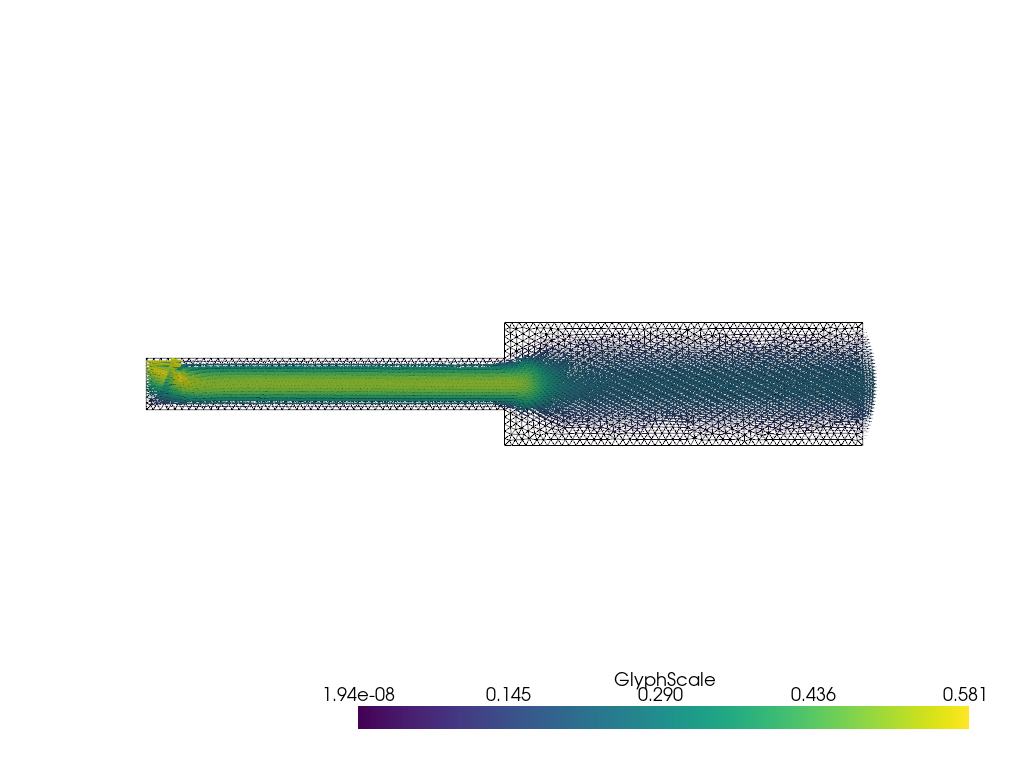

In [ ]:
topology, cell_types, geometry = vtk_mesh(V)
values = np.zeros((geometry.shape[0], 3), dtype=np.float64)
values[:, : len(u_n)] = u_n.x.array.real.reshape((geometry.shape[0], len(u_n)))

function_grid = pyvista.UnstructuredGrid(topology, cell_types, geometry)
function_grid["u"] = values
glyphs = function_grid.glyph(orient="u", factor=0.01)

tdim = mesh.topology.dim
mesh.topology.create_connectivity(tdim, tdim)
grid = pyvista.UnstructuredGrid(*vtk_mesh(mesh, tdim))

plotter = pyvista.Plotter()
plotter.add_mesh(grid, style="wireframe", color="k", line_width=0.5)
plotter.add_mesh(glyphs, scalars="GlyphScale", cmap="viridis")
plotter.view_xy()

if not pyvista.OFF_SCREEN:
    plotter.show()
else:
    plotter.screenshot("glyphs.png")

ValueError: The length of c must match either the number of points or the number of triangles

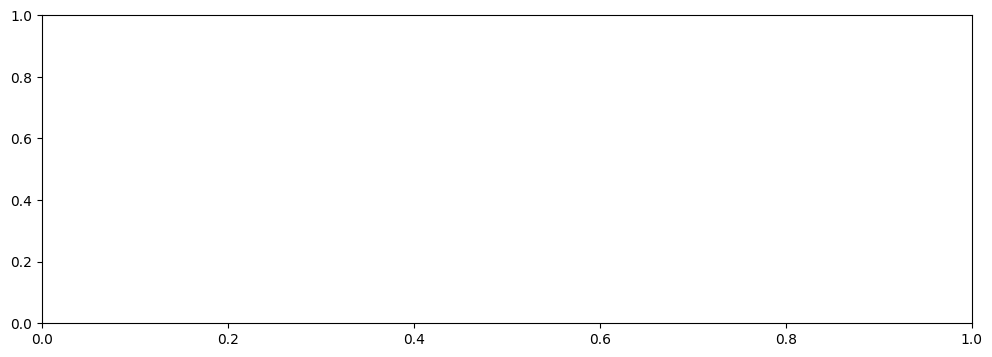

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.tri as tri

# get mesh coordinates
coords = mesh.geometry.x
x, y = coords[:, 0], coords[:, 1]

# get velocity magnitude at each node
u_values = u_n.x.array.real.reshape(-1, 2)
u_mag = np.linalg.norm(u_values, axis=1)

# triangulate and plot
triangulation = tri.Triangulation(x, y)
plt.figure(figsize=(12, 4))
plt.tripcolor(triangulation, u_mag, cmap="viridis", shading="gouraud")
plt.colorbar(label="velocity magnitude (m/s)")
plt.axis("equal")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Velocity magnitude")
plt.tight_layout()
plt.savefig("velocity.png", dpi=150)
plt.show()